(phillips_priors)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 先验、逃逸与学习循环

```{index} single: Phillips Curve; Priors and Learning Cycles
```

```{contents} Contents
:depth: 2
```

## 概述

> 波旁家族什么都记得，却什么也没学到。
>
> —— 夏尔·莫里斯·德·塔列朗

本讲座是 {doc}`phillips_learning` 的续篇。

它遵循 {cite}`SargentWilliams2005` 的方法，该文献推广了 {cite}`Sargent1999` 第 8 章以及 {cite}`ChoWilliamsSargent2002`（CWS）的适应性模型，我们在 {doc}`phillips_escaping_nash` 中推导过后者的逃逸动态。

在 {doc}`phillips_learning` 中，政府通过递归最小二乘法估计其菲利普斯曲线。

那是一种非常特定的学习方式。

最小二乘学习者的行为就好像它相信其模型的系数遵循一个特定的随机游走——具有特定新息协方差矩阵的随机游走。

在这里，我们让政府对其系数如何漂移持有*任意*先验信念，用协方差矩阵 $V$ 来编码，并考察这种先验的形状如何影响驱动模型的两种力量：

* **均值动态**，它将政府的信念拉向自证（纳什）均衡；以及
* **逃逸动态**，它偶尔将信念推离自证均衡，转向低通胀的拉姆齐结果。

我们将发现三件事。

1. 某些先验会使自证均衡变得*不稳定*，从而使均值动态本身产生反复出现的反通胀——这是一种由霍普夫分岔产生的**学习循环**，而非罕见的随机逃逸。
2. 先验决定了逃逸的*方向*和*速度*；但在每种情况下，逃逸的目的地都是拉姆齐结果。
3. 先验解释了一个由来已久的谜题：为什么西姆斯和钟的模拟会逃离纳什通胀并*永远*停留在拉姆齐附近，而 {cite}`Sargent1999` 和 CWS 的模拟却只是逃逸后又被拉回。

在整个讲座中，我们使用 {doc}`phillips_escaping_nash` 中可解析处理的**静态**模型，在该模型中政府对失业率关于通胀和常数进行简单回归。

让我们从导入开始：

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from scipy.integrate import solve_ivp

## 静态模型

真实经济是 {cite}`KydlandPrescott1977` 自然率模型的一个版本：

```{math}
:label: pp_truth

\begin{aligned}
U_n &= u - (\pi_n - \hat x_n) + \sigma_1 W_{1n}, \qquad u > 0, \\
\pi_n &= x_n + \sigma_2 W_{2n}, \\
\hat x_n &= x_n,
\end{aligned}
```

其中 $U_n$ 是失业率，$\pi_n$ 是通货膨胀率，$x_n$ 是政府设定的通胀的系统性部分，$\hat x_n$ 是公众的（理性）预测，$W_n = (W_{1n}, W_{2n})^\top$ 是独立同分布的标准高斯噪声。

由于 $\pi_n - \hat x_n = \sigma_2 W_{2n}$，真实的失业率是 $U_n = u - \sigma_2 W_{2n} + \sigma_1 W_{1n}$——无论系统性政策如何，它都围绕自然率 $u$ 波动。

政府并不知道这一点。

在**静态模型**中，政府通过对失业率关于当前通胀和常数进行回归来拟合一个非预期性的菲利普斯曲线，

```{math}
:label: pp_belief

U_n = a + b\, \pi_n + \eta_n ,
```

信念向量为 $\gamma = (a, b)$（截距和斜率），并将 $\eta_n$ 视为外生冲击。

```{warning}
{doc}`phillips_escaping_nash` 研究的是同一个静态模型，但信念向量的排列顺序相反，写作
$\gamma = (\gamma_1, \gamma_{-1})$，*斜率*在前，回归量为 $\Phi = (\pi, 1)$，遵循
{cite}`ChoWilliamsSargent2002` 的做法。

在这里，我们把*截距*放在前面，$\Phi = (1, \pi)$，遵循 {cite}`SargentWilliams2005` 的做法。

这两者其实是同一个模型在不同坐标下的表示：$a = \gamma_{-1}$ 且 $b = \gamma_1$，因此本讲中的自我确认信念
$(2u, -1)$ 对应于上一讲中的 $(-1, u(1+\theta^2))$，其中 $\theta = 1$。

诸如 $M$、$V$ 和 $P$ 这样的矩阵，其行和列也相应地进行了转置。
```

在相信 {eq}`pp_belief` 的前提下，政府求解菲尔普斯问题——最小化 $\hat{\mathbb{E}} \sum_n \delta^n (U_n^2 + \pi_n^2)$——其静态最优反应将通胀设定为常数

```{math}
:label: pp_bestresp

x(\gamma) = -\frac{a\, b}{1 + b^2} .
```

In [2]:
class StaticPhillips:
    "The static Sargent-Williams model: government regresses U on (1, π)."

    def __init__(self, u=5.0, σ1=0.3, σ2=0.3):
        self.u, self.σ1, self.σ2 = u, σ1, σ2
        self.σ = σ1                       # govt regression error std = σ1

    def x(self, γ):
        "Government best response (systematic inflation) given beliefs γ."
        a, b = γ
        return -a * b / (1 + b**2)

    def M(self, γ):
        "Second moment matrix E[ΦΦ'] of regressors Φ = (1, π), given γ."
        x = self.x(γ)
        return np.array([[1.0, x], [x, x**2 + self.σ2**2]])

    def g_bar(self, γ):
        "Least squares moment E[Φ(U - Φ'γ)] under the data γ generates."
        u, σ2 = self.u, self.σ2
        x = self.x(γ)
        E_ΦU = np.array([u, x * u - σ2**2])
        return E_ΦU - self.M(γ) @ γ

有三个信念向量值得命名。

* **信念 1（纳什）：** $b = -1$，截距使政府设定 $x = u$，这是 {cite}`KydlandPrescott1977` 的时间一致性结果。
* **信念 2（拉姆齐）：** $b = 0$，因此政府认为*不存在*权衡，设定 $x = 0$。
* **信念 3（归纳）：** 在动态版本中，当前和滞后通胀的系数之和为零，这对于一个有耐心的政府来说也会使通胀趋向 $0$。

## 自证均衡

自证均衡是一个能自我再生的信念 $\bar\gamma$：当政府依据 $\bar\gamma$ 行事时所产生的数据，使得总体回归系数恰好等于 $\bar\gamma$，即 $\bar g(\bar\gamma) = 0$。

对于静态模型，这可以手工轻松求解。

斜率为 $b = \operatorname{cov}(U, \pi)/\mathbb{V}[\pi] = -\sigma_2^2/\sigma_2^2 = -1$，均值匹配给出截距 $a = u + x(\bar\gamma)$。

将最优反应 {eq}`pp_bestresp`（$b = -1$）代入，得到 $x = a/2$，因此 $a = u + a/2$，即 $a = 2u$。

In [3]:
model = StaticPhillips(u=5.0, σ1=0.3, σ2=0.3)
γ_sce = np.array([2 * model.u, -1.0])

print(f"self-confirming beliefs  γ = {γ_sce}  (intercept 2u, slope -1)")
print(f"self-confirming inflation x = {model.x(γ_sce):.2f}  (= Nash = u)")
print(f"check g_bar(γ_sce) = {model.g_bar(γ_sce)}")

self-confirming beliefs  γ = [10. -1.]  (intercept 2u, slope -1)
self-confirming inflation x = 5.00  (= Nash = u)
check g_bar(γ_sce) = [0. 0.]


自证均衡的通胀率等于纳什（时间一致性）结果 $u = 5$，即使政府的模型是设定错误的。

政府的非预期性菲利普斯曲线在均衡路径*上*与真实模型在观测上等价，但在均衡路径*之外*是错误的——而这正是它的适应性行为反复试探的地方。

## 漂移信念与卡尔曼滤波

现在我们让政府变得具有适应性。

依照 {cite}`SargentWilliams2005`，政府相信其菲利普斯曲线的系数以随机游走的形式*漂移*，

```{math}
:label: pp_drift

\alpha_n = \alpha_{n-1} + \Lambda_n,
\qquad
\operatorname{cov}(\Lambda_n) = V ,
```

它通过卡尔曼滤波形成其估计值 $\gamma_n = \hat\alpha_{n \mid n-1}$。

协方差矩阵 $V$ 是政府对**参数漂移的先验信念**——这是我们要放开的对象。

对于回归量 $\Phi_n = (1, \pi_n)^\top$，卡尔曼滤波的大样本近似（见 {cite}`BenvenisteMetivierPriouret1990`）为

```{math}
:label: pp_kalman

\begin{aligned}
\gamma_{n+1} &= \gamma_n + P_n \Phi_n\left(U_n - \Phi_n^\top \gamma_n\right), \\
P_{n+1} &= P_n - P_n M(\gamma_n) P_n + \sigma^{-2} V ,
\end{aligned}
```

其中 $\sigma^2$ 是政府赋予其回归误差 $\eta_n$ 的方差。

对于固定的 $\gamma$，矩阵 $P_n$ 收敛到代数里卡蒂方程的解

```{math}
:label: pp_riccati

- P M(\gamma) P + \sigma^{-2} V = 0 .
```

与 {doc}`phillips_learning` 的联系是精确的。

固定增益递归最小二乘法是这样一种特殊情形：政府的先验为 $V = V^* \equiv \epsilon^2 \sigma^2 M(\bar\gamma)^{-1}$ 且 $\sigma = \sigma_1$；此时 {eq}`pp_riccati` 给出 $P = \epsilon M(\bar\gamma)^{-1}$，而 {eq}`pp_kalman` 简化为上一讲中增益为 $\epsilon$ 的递归最小二乘算法。

In [4]:
def solve_riccati(V, M, σ):
    "Symmetric positive-definite P solving P M P = σ^{-2} V."
    W = V / σ**2
    Mh = sqrtm(M).real
    Mh_inv = np.linalg.inv(Mh)
    return Mh_inv @ sqrtm(Mh @ W @ Mh).real @ Mh_inv

M_sce = model.M(γ_sce)
V_star = model.σ**2 * np.linalg.inv(M_sce)      # the RLS prior (ε = 1)
P_star = solve_riccati(V_star, M_sce, model.σ)

print("RLS prior gives P = M^{-1}?", np.allclose(P_star, np.linalg.inv(M_sce)))

RLS prior gives P = M^{-1}? True


## 均值动态与 E-稳定性

与 {doc}`phillips_learning` 一样，信念由均值动态所组织——现在是关于 $(\gamma, P)$ 的*联合*常微分方程，

```{math}
:label: pp_ode

\dot\gamma = P\, \bar g(\gamma),
\qquad
\dot P = \sigma^{-2} V - P M(\gamma) P .
```

{eq}`pp_ode` 的一个静止点满足 $\bar g(\gamma) = 0$ 且 $P = $ 里卡蒂解——即一个自证均衡。

局部稳定性取决于自证均衡处 $\bar g$ 的雅可比矩阵。

对于静态模型，这可以求得闭式解，

```{math}
:label: pp_jacobian

\frac{\partial \bar g}{\partial \gamma}(\bar\gamma)
= - \begin{bmatrix} \tfrac12 & u \\[1mm] \tfrac12 u & u^2 + \sigma_2^2 \end{bmatrix} .
```

In [5]:
def jacobian(model, γ, h=1e-6):
    "Numerical Jacobian of g_bar at γ."
    J = np.zeros((2, 2))
    for j in range(2):
        gp, gm = γ.copy(), γ.copy()
        gp[j] += h; gm[j] -= h
        J[:, j] = (model.g_bar(gp) - model.g_bar(gm)) / (2 * h)
    return J

J = jacobian(model, γ_sce)
print("∂g/∂γ at SCE =\n", J.round(3))

∂g/∂γ at SCE =
 [[ -0.5   -5.  ]
 [ -2.5  -25.09]]


在递归最小二乘法下，{eq}`pp_ode` 中的 $P$ 分块会解耦，稳定性由 $M^{-1}\,\partial\bar g/\partial\gamma$ 的特征值决定——这就是 {cite}`EvansHonkapohja2001` 提出的经典 **E-稳定性**条件。

In [6]:
eig_rls = np.linalg.eigvals(np.linalg.inv(M_sce) @ J)
print(f"E-stability eigenvalues (RLS): {eig_rls.round(3)}")
print("both negative ⇒ the SCE is E-stable, and least squares converges to Nash")

E-stability eigenvalues (RLS): [-0.5 -1. ]
both negative ⇒ the SCE is E-stable, and least squares converges to Nash


两个特征值均为负——其中一个恰好等于 $-\tfrac12$，这正是 {doc}`phillips_learning` 中出现过的临界值。

因此，在最小二乘法下，信念收敛到纳什自证均衡。

但这一化简依赖于特殊的递归最小二乘先验。

在*一般*先验 $V$ 下，$P$ 分块**不会**解耦，稳定性反而由 $\bar P\, \partial\bar g/\partial\gamma$ 的特征值决定——其中 $\bar P$ 是该先验下的里卡蒂解。

关于参数漂移的先验信念现在会影响自证均衡是否稳定。

## 学习循环

这里是论文最引人注目的结果：某些先验会使自证均衡变得*不稳定*，并通过霍普夫分岔产生一个**稳定的极限循环**。

我们通过*收紧政府对斜率系数的先验*来说明这一点，从递归最小二乘先验 $V^*$ 出发，用因子 $\lambda \in [0, 1]$ 收缩与斜率相关的项：

```{math}
:label: pp_Vlambda

V(\lambda) = \begin{bmatrix} V^*_{11} & \sqrt\lambda\, V^*_{12} \\ \sqrt\lambda\, V^*_{12} & \lambda\, V^*_{22} \end{bmatrix} .
```

对每个 $\lambda$，我们求解里卡蒂方程并观察 $\bar P(\lambda)\, \partial\bar g/\partial\gamma$ 特征值中最大实部：当该值为正时，自证均衡是不稳定的。

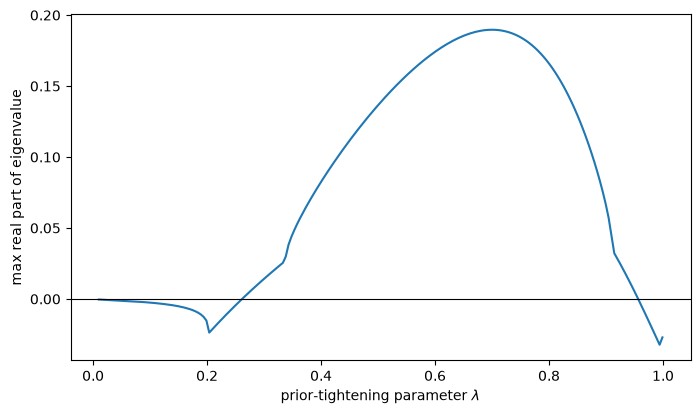

In [7]:
def V_tighten_slope(λ, V_star):
    V = V_star.copy()
    V[0, 1] = V[1, 0] = np.sqrt(λ) * V_star[0, 1]
    V[1, 1] = λ * V_star[1, 1]
    return V

ε = 0.05                                   # gain (sets the timescale)
λ_grid = np.linspace(0.01, 0.999, 200)
max_re = []
for λ in λ_grid:
    V = ε**2 * V_tighten_slope(λ, V_star)
    P = solve_riccati(V, M_sce, model.σ)
    max_re.append(np.linalg.eigvals(P @ J).real.max())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(λ_grid, max_re)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'prior-tightening parameter $\lambda$')
ax.set_ylabel('max real part of eigenvalue')
plt.show()

在一个中间范围的 $\lambda$ 内，最大实部变为*正值*：自证均衡失去稳定性。

根据霍普夫分岔定理（见 {cite}`Perko1996`），当实部越过零时，会分岔出一个唯一的稳定极限循环——{cite}`Bullard1994` 称之为*学习均衡*。

让我们在 $\lambda = 0.7$（充分位于不稳定范围内）处对回归系数的均值动态进行积分，将 $P$ 固定在其里卡蒂值处，并描绘该循环。

In [8]:
λ = 0.7
V = ε**2 * V_tighten_slope(λ, V_star)
P_bar = solve_riccati(V, M_sce, model.σ)

def coeff_ode(t, γ):
    return P_bar @ model.g_bar(γ)

sol = solve_ivp(coeff_ode, [0, 2500], γ_sce + np.array([0.3, 0.05]),
                max_step=1.0, rtol=1e-9, atol=1e-11, dense_output=True)
a_path, b_path = sol.y
x_path = -a_path * b_path / (1 + b_path**2)

# isolate one mature cycle for the phase plot
mask = sol.t > sol.t[-1] - 800

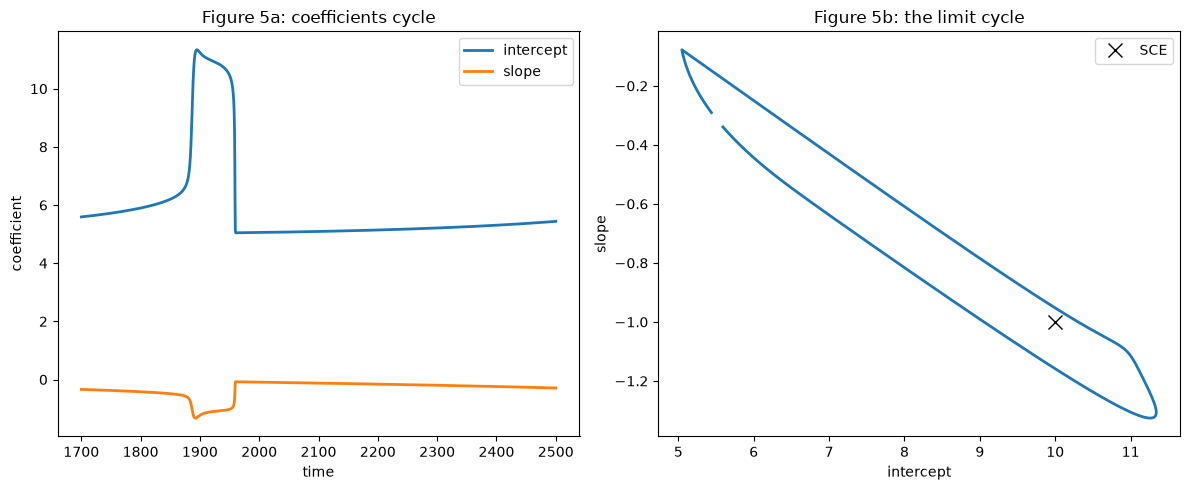

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sol.t[mask], a_path[mask], label='intercept', lw=2)
axes[0].plot(sol.t[mask], b_path[mask], label='slope', lw=2)
axes[0].set_xlabel('time')
axes[0].set_ylabel('coefficient')
axes[0].set_title('Figure 5a: coefficients cycle')
axes[0].legend()

axes[1].plot(a_path[mask], b_path[mask], lw=2)
axes[1].plot(*γ_sce, 'kx', ms=10, label='SCE')
axes[1].set_xlabel('intercept')
axes[1].set_ylabel('slope')
axes[1].set_title('Figure 5b: the limit cycle')
axes[1].legend()

plt.tight_layout()
plt.show()

信念稳定在围绕自证均衡的一个闭合轨道上。

由于通胀通过最优反应 {eq}`pp_bestresp` 是系数的函数，信念中的循环表现为通胀在纳什和拉姆齐结果之间振荡的循环。

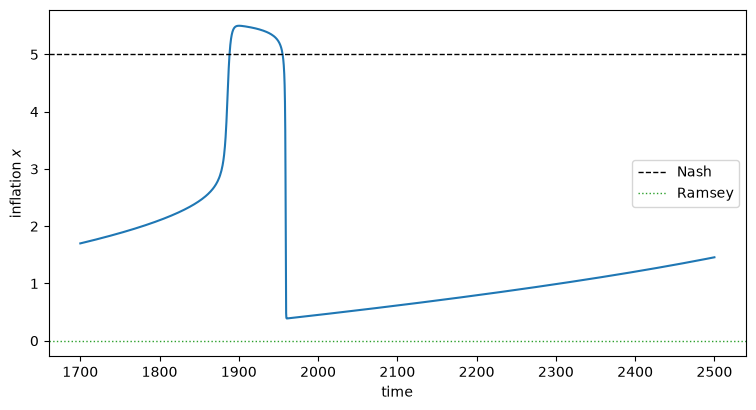

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sol.t[mask], x_path[mask])
ax.axhline(model.u, color='k', ls='--', lw=1, label='Nash')
ax.axhline(0, color='C2', ls=':', lw=1, label='Ramsey')
ax.set_xlabel('time')
ax.set_ylabel('inflation $x$')
ax.legend()
plt.show()

这与 {doc}`phillips_learning` 中的逃逸在性质上不同。

在那里，反通胀是*罕见*事件，由不太可能出现的冲击序列驱动；在这些事件之间，系统停留在纳什状态。

而这里，反通胀是时间序列的一个*典型*特征，由均值动态本身产生——一种即使增益缩小到零也依然持续存在的确定性循环。

## 逃逸动态与逃逸方向

对于使自证均衡保持稳定的先验，反通胀又变回罕见的逃逸事件，与 {doc}`phillips_learning` 中的情形完全一致。

大偏差理论（在 {doc}`phillips_learning` 的入门材料中展开，并通过 {cite}`Williams2019` 应用于此）将最可能的逃逸刻画为一个控制问题的解：施加代价最小的信念扰动，将信念推离 $\bar\gamma$ 固定距离。

*瞬时*逃逸方向有一个非常简洁的刻画：它是信念-新息协方差 $Q(\bar\gamma, \bar P) = \hat V$——即先验本身——的最大特征值对应的特征向量。

In [11]:
w, vecs = np.linalg.eigh(V_star)            # baseline prior V*
v_escape = vecs[:, np.argmax(w)]
v_escape = v_escape / np.linalg.norm(v_escape)

# scale the escape so the slope moves from -1 up to 0
t_star = 1.0 / v_escape[1]
terminal = γ_sce + t_star * v_escape

print(f"escape direction  ≈ {v_escape.round(3)}   (∝ [-u, 1])")
print(f"terminal beliefs  ≈ {terminal.round(2)}   (Belief 2 = [u, 0] = Ramsey)")

escape direction  ≈ [-0.981  0.195]   (∝ [-u, 1])
terminal beliefs  ≈ [4.98 0.  ]   (Belief 2 = [u, 0] = Ramsey)


对于基准先验，逃逸方向正比于 $(-u, 1)$，它使信念从纳什 $(2u, -1)$ 移向 $(u, 0)$——即支持拉姆齐结果的信念 2。

因此，逃逸一旦发生，就是朝着零通胀方向的运动。

不同的先验会改变逃逸的*路径*并改变逃逸的*速率*——收紧斜率先验甚至可能彻底使均衡失稳（如上面的循环所示），而收紧截距先验则会加快逃逸速度——但目的地始终是拉姆齐结果。

## 西姆斯的不收敛现象

我们现在可以解决 {doc}`phillips_two_stories` 中提到的一个谜题。

{cite}`Sims1988` 和 {cite}`Chung1990` 的模拟从纳什自证结果开始，逃逸到低通胀，然后似乎*无限期地*停留在那里。

而 {cite}`Sargent1999` 和 CWS 的模拟则是逃逸后被一再拉回。

{cite}`SargentWilliams2005` 将这一差异归因于一个单一的建模选择：政府是否对其回归误差赋予了*正确*的方差。

当 $\sigma = \sigma_1$ 时——如在自证均衡中那样，此时回归 {eq}`pp_belief` 与真实模型 {eq}`pp_truth` 一致——政府能正确地分解它所观察到的变异。

西姆斯则使用了 $\sigma \neq \sigma_1$（且没有缩小增益），这*错误地分配*了观测到的变异，从而产生了长期、也许是永久性的偏离自证均衡的情形。

在我们模拟任何东西之前，这一机制在里卡蒂方程 {eq}`pp_riccati` 中就已经显现出来。

一个对其回归误差赋予*过少*方差的政府，必须将它所观察到的变异归因于其他因素，而唯一可用的其他因素就是其自身系数的漂移。

因此 $\sigma < \sigma_1$ 会使稳态的 $P$ 膨胀，而 $P$ 正是在 {eq}`pp_kalman` 中乘以每个预测误差的量。

因此，低估误差方差会使政府*学习得更快*——而这恰恰削弱了均值动态的拉力。

In [12]:
def effective_gain(model, σ_govt, ε, λ=1.0):
    "Steady-state weight the filter puts on a single forecast error at the SCE."
    V = ε**2 * V_tighten_slope(λ, V_star)
    P = solve_riccati(V, M_sce, σ_govt)
    Φ = np.array([1.0, model.x(γ_sce)])
    return (P @ Φ)[0] / (σ_govt**2 + Φ @ P @ Φ)

ε_common = 0.0002
for σ_govt, tag in ((model.σ1, 'σ = σ1  (correct) '), (0.1, 'σ ≠ σ1  (Sims)   ')):
    print(f"{tag}: effective gain = {effective_gain(model, σ_govt, ε_common):.5f}")

σ = σ1  (correct) : effective gain = 0.00222
σ ≠ σ1  (Sims)   : effective gain = 0.05660


即使先验 $V$ 和尺度 $\varepsilon$ 在两次运行中都相同，低估误差方差也会使有效增益放大二十多倍。

现在让我们在两种设定下模拟静态模型，保持 $\varepsilon$ 固定不变，这样两者*唯一*的差异就在于政府对其自身回归误差所赋予的方差。

In [13]:
def simulate(model, σ_govt, ε, λ=1.0, T=3000, seed=0):
    "Static Kalman-filter learning; σ_govt is the government's assumed error std."
    rng = np.random.default_rng(seed)
    u, σ1, σ2 = model.u, model.σ1, model.σ2

    V = ε**2 * V_tighten_slope(λ, V_star)
    γ = γ_sce.copy()
    P = ε * np.linalg.inv(M_sce)
    infl = np.empty(T)

    for n in range(T):
        x = model.x(γ)
        w1, w2 = rng.standard_normal(2)
        π = x + σ2 * w2
        U = u - σ2 * w2 + σ1 * w1                 # truth uses σ1
        Φ = np.array([1.0, π])
        denom = σ_govt**2 + Φ @ P @ Φ
        γ = γ + (P @ Φ) / denom * (U - Φ @ γ)
        P = P - np.outer(P @ Φ, Φ @ P) / denom + V / σ_govt**2
        infl[n] = π
    return infl

T_sim, seeds = 6000, range(10)

def summarize(σ_govt):
    "Mean inflation and time near Ramsey, across seeds."
    paths = [simulate(model, σ_govt=σ_govt, ε=ε_common, T=T_sim, seed=s)
             for s in seeds]
    return (np.array([p.mean() for p in paths]),
            np.array([(p < 2).mean() for p in paths]))

mean_base, ramsey_base = summarize(model.σ1)
mean_sims, ramsey_sims = summarize(0.1)

print(f"{'seed':>4} | {'σ = σ1: mean π':>15} {'near Ramsey':>12}"
      f" | {'σ ≠ σ1: mean π':>15} {'near Ramsey':>12}")
for s in seeds:
    print(f"{s:>4} | {mean_base[s]:>15.2f} {ramsey_base[s]:>11.0%}"
          f" | {mean_sims[s]:>15.2f} {ramsey_sims[s]:>11.0%}")
print(f"\nnever escaped in {T_sim} periods:  "
      f"σ = σ1: {np.sum(ramsey_base < 0.01)}/{len(seeds)} paths,   "
      f"σ ≠ σ1: {np.sum(ramsey_sims < 0.01)}/{len(seeds)} paths")

seed |  σ = σ1: mean π  near Ramsey |  σ ≠ σ1: mean π  near Ramsey
   0 |            4.99          0% |            2.26         58%
   1 |            5.04          0% |            2.24         58%
   2 |            1.16         79% |            1.70         69%
   3 |            1.10         80% |            2.09         61%
   4 |            4.39         10% |            1.58         73%
   5 |            5.02          0% |            2.24         58%
   6 |            0.43         94% |            1.71         69%
   7 |            0.50         92% |            2.12         61%
   8 |            5.02          0% |            1.99         62%
   9 |            1.82         64% |            1.96         64%

never escaped in 6000 periods:  σ = σ1: 4/10 paths,   σ ≠ σ1: 0/10 paths


这两列的表现相当不同，而这种差异关乎经济*多频繁地*离开纳什水平，而不在于它逃逸后去往何处。

在误差方差设定正确的情况下，逃逸是一个真正罕见的事件：若干条样本路径在六千个周期内始终停留在纳什利率附近，从未逃逸；其余路径则在某个时刻逃逸，此后又被拉回到拉姆齐水平附近。

而在西姆斯的错误分配下，*每条*路径都会逃逸，并且每一条都将大部分时间停留在拉姆齐水平附近。

三个种子无需任何挑选就能说明问题：种子 0 从未逃逸，种子 4 反复逃逸并每次都被拉回，种子 6 逃逸后则长时间远离纳什水平。

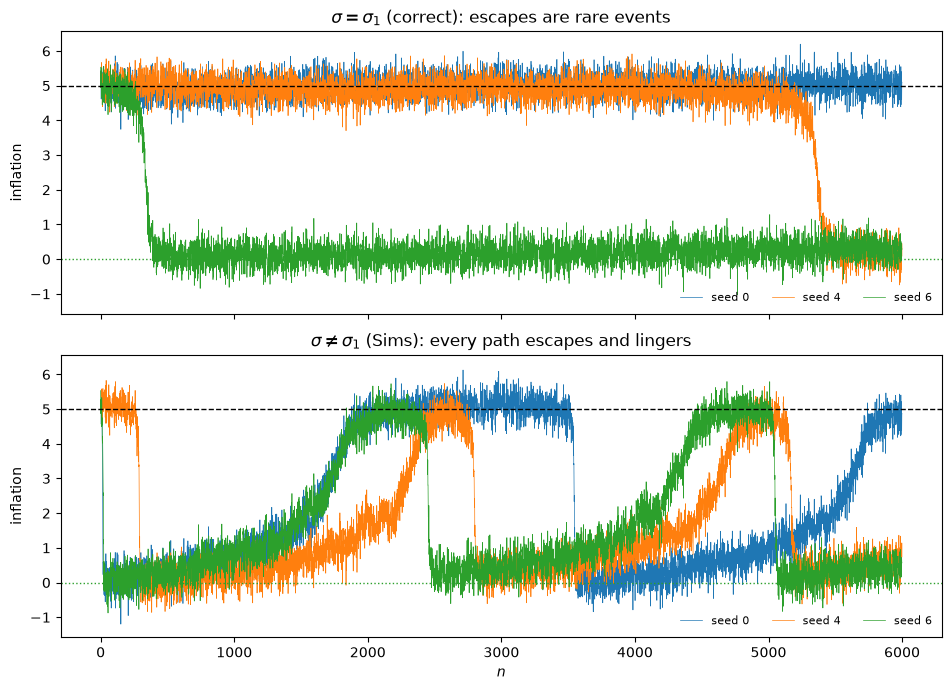

In [14]:
show = (0, 4, 6)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True, sharey=True)
for s in show:
    axes[0].plot(simulate(model, σ_govt=model.σ1, ε=ε_common, T=T_sim, seed=s),
                 lw=0.5, label=f'seed {s}')
    axes[1].plot(simulate(model, σ_govt=0.1, ε=ε_common, T=T_sim, seed=s),
                 lw=0.5, label=f'seed {s}')
for ax, title in zip(axes, [r'$\sigma = \sigma_1$ (correct): escapes are rare events',
                            r'$\sigma \neq \sigma_1$ (Sims): every path escapes and lingers']):
    ax.axhline(model.u, color='k', ls='--', lw=1)
    ax.axhline(0, color='C2', ls=':', lw=1)
    ax.set_ylabel('inflation')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc='lower right')
axes[1].set_xlabel('$n$')
plt.tight_layout()
plt.show()

在误差方差设定正确的情况下，均值动态占主导地位：经济停留在纳什水平，只有异常连续的一连串冲击才能将其撼动——这正是 {doc}`phillips_learning` 和 {doc}`phillips_escaping_nash` 中呈现的罕见逃逸图景。

而在西姆斯的错误分配下，政府学习得太快，以至于均值动态无法将其维持住，于是它几乎立即逃逸，其行为就好像已经*永久*学会了一个足够好的自然率假说版本。

正如 {cite}`SargentWilliams2005` 所言，这种差异可以用两种等价的方式来理解：要么是西姆斯允许了过多的参数漂移以至于无法收敛，要么是他没有让政府对其回归误差归因足够多的变异。

## 结论

自由参数是危险的，正如阿瑟·戈德伯格和罗伯特·卢卡斯所警告的那样。

本讲座中的政府在其信念漂移的协方差矩阵 $V$ 中携带着自由参数。

但这些参数换来了一些东西：后续的实证研究 {cite}`SargentWilliamsZha2006` 表明，根据战后美国数据估计 $V$，可以让该模型反推出一系列政策制定者关于菲利普斯曲线不断演变的主观模型，从而使美国通胀实际的兴衰历程得到合理解释——这正是 {doc}`phillips_two_stories` 中平反故事的量化版本。

关于系数漂移的协方差本身随时间变化的相关证据见 {cite}`CogleySargent2005`。

### 估计出的信念是否现实？

那一实证上的成功也伴随着一个挑战，而这个挑战其实是关于*先验*本身的挑战。

为了拟合数据，{cite}`SargentWilliamsZha2006` 估计出一个很大的漂移协方差 $V$——这意味着一个对新数据如此开放的政府，其对货币传导机制的信念每月都会大幅摇摆。

{cite}`Primiceri2006`、克里斯托弗·西姆斯，以及坦率地说，{cite}`Sargent2008` 本人在其学会主席致辞中，都提出了异议：这种剧烈波动的信念是*不现实的*——由此推算出的政府对失业率的预测很差，持有的观点也是任何真实的中央银行都不会持有的。

{cite}`CarboniEllison2009` 通过用美联储实际产生的数据来约束先验，回应了这一异议。

他们在要求模型的信念必须能再现美联储《绿皮书》中公布的失业率预测这一约束下重新估计了模型——这为学习模型施加了一种理性预期计量经济学中常见的跨方程约束。

施加这一约束后，估计出的 $V$ 缩小了几个数量级，消除了剧烈的信念波动，但低频的"征服"故事依然完好无损：一种*稳定*演化的美联储信念，仍然能够解释通胀的兴衰。

事实证明，那些剧烈波动的信念，不过是在对 {cite}`Sargent1999` 从未打算解释的高频波动进行过拟合而已。

本讲座的寓意很直接：先验 $V$ 并非一个可以自由最大化的讨厌参数——它是一个经济对象，用关于政策制定者实际信念的独立证据将其确定下来，才使平反故事变得可信。

更广泛的信息是：一个适应性政府*如何*学习——它带入自身信念漂移中的先验——并非一个技术细节。

它决定了经济是收敛到纳什状态、在纳什和拉姆齐之间循环，还是逃逸到拉姆齐状态并停留在那里。

{doc}`phillips_lost_conquest` 将同样的工具——固定增益学习、预期效用菲尔普斯问题以及自证均衡——带入当下，用以解释美联储对 2020 年代通胀的应对。

{doc}`phillips_drifts_volatilities` 随后为本系列画上句点，对这整套论述进行了一次实证检验：将一个带漂移系数、随机波动率的向量自回归模型拟合到战后数据，探究大通胀在多大程度上源于信念漂移，又在多大程度上仅仅是运气不佳。

## 练习

```{exercise-start}
:label: ppr_ex1
```

上文的学习循环收紧了对*斜率*系数的先验。

改为收紧对*截距*系数的先验——使用

$$
V(\lambda) = \begin{bmatrix} \lambda\, V^*_{11} & \sqrt\lambda\, V^*_{12} \\ \sqrt\lambda\, V^*_{12} & V^*_{22} \end{bmatrix}
$$

——这*不会*使自证均衡失稳。

请通过绘制该截距收紧族中 $\bar P(\lambda)\,\partial\bar g/\partial\gamma$ 特征值最大实部关于 $\lambda$ 的图像来验证这一点，并确认其始终为负。

```{exercise-end}
```

```{solution-start} ppr_ex1
:class: dropdown
```

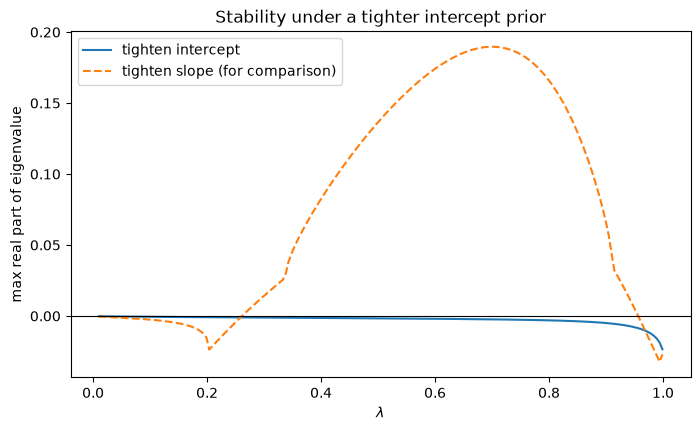

In [15]:
def V_tighten_intercept(λ, V_star):
    V = V_star.copy()
    V[0, 0] = λ * V_star[0, 0]
    V[0, 1] = V[1, 0] = np.sqrt(λ) * V_star[0, 1]
    return V

max_re_int = []
for λ in λ_grid:
    V = ε**2 * V_tighten_intercept(λ, V_star)
    P = solve_riccati(V, M_sce, model.σ)
    max_re_int.append(np.linalg.eigvals(P @ J).real.max())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(λ_grid, max_re_int, label='tighten intercept')
ax.plot(λ_grid, max_re, ls='--', label='tighten slope (for comparison)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('max real part of eigenvalue')
ax.set_title('Stability under a tighter intercept prior')
ax.legend()
plt.show()

收紧截距先验使最大实部对于所有 $\lambda$ 都保持为负：自证均衡保持稳定，因此不存在学习循环。

正如 {cite}`SargentWilliams2005` 所示，这种先验确实仍会改变*逃逸*动态——它会加快逃逸——但不会推翻均值动态。

```{solution-end}
```

```{exercise-start}
:label: ppr_ex2
```

瞬时逃逸方向是先验协方差 $\hat V$ 的主特征向量。

请确认该方向对先验的整体*尺度*是稳健的，但对其*形状*是敏感的。

分别计算基准先验 $V^*$ 和斜率收紧先验 $V(\lambda = 0.5)$ 对应的逃逸方向（以及所隐含的终端信念），并比较二者将政府的信念分别送往何处。

```{exercise-end}
```

```{solution-start} ppr_ex2
:class: dropdown
```

In [16]:
def escape_terminal(V):
    w, vecs = np.linalg.eigh(V)
    v = vecs[:, np.argmax(w)]
    v = v / np.linalg.norm(v)
    if v[1] < 0:                      # orient toward increasing slope
        v = -v
    return γ_sce + (1.0 / v[1]) * v, v

for name, V in [("baseline V*", V_star),
                ("slope-tightened V(0.5)", V_tighten_slope(0.5, V_star))]:
    term, v = escape_terminal(V)
    print(f"{name:24s}: direction {v.round(3)}, terminal {term.round(2)}")

baseline V*             : direction [-0.981  0.195], terminal [4.98 0.  ]
slope-tightened V(0.5)  : direction [-0.99  0.14], terminal [2.9 0. ]


两种先验都将信念导向斜率为 $0$ 的终端点——即拉姆齐信念——但沿着不同的方向，且二者到达的截距差异相当大：斜率收紧先验落在的截距略高于基准情形截距的一半。

在对政策有意义的层面上，目的地是稳健的：斜率为 $0$ 意味着政府认为不存在可利用的权衡关系，此时 {eq}`pp_bestresp` 无论截距如何，都会将通胀设为零。

而*路径*，以及逃逸在拉姆齐线上具体终止于何处，则取决于先验的形状。

```{solution-end}
```